# Modelos de eventos discretos con SimPy
En este Notebook veremos el módulo **SimPy** para la simulación de eventos discretos y veran cómo construir un modelo simple implementado con SimPy, con algunos ejercicios sencillos intercalados.

## Importar los módulos a utilizar



In [1]:
# %matplotlib inline
import simpy
import random
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

## Un modelo de una pista de esqui
Consideraremos un sistema de una pequeña operación de esquí con un único telesferico.

### Llegada de esquiadores

Comenzamos con un modelo de los clientes (esquiadores) que llegan a la instalación. Al principio consideramos que los clientes llegan de forma aleatoria con una frecuencia media que es constante durante el día. En el siguiente paso, haremos que el modelo de llegadas sea más realista.

El tiempo entre llegadas es aleatorio y puede modelarse con una distribución exponencial. La función de densidad de probabilidad de la distribución exponencial con media $\frac{1}{\lambda}$ es

$$f(t) = \lambda \mathrm{e}^{-\lambda t},$$

y la función de distribución de probabilidad es

$$F(t) = \mathrm{Pr}\,(T \le t) = \int_0^t f(\tau)d\tau = 1 - \mathrm{e}^{-\lambda t}.$$

Las dos funciones se muestran en la gráfica a continuación.



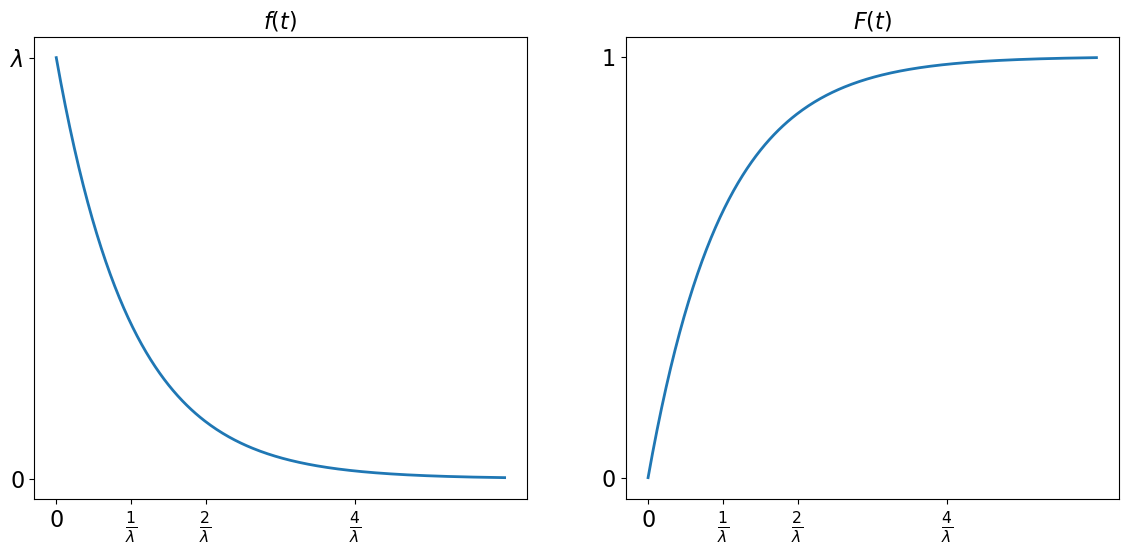

In [3]:
font_size = 16
mpl.rcParams['xtick.labelsize'] = font_size 
mpl.rcParams['ytick.labelsize'] = font_size 
mpl.rcParams['axes.titlesize'] = font_size 
mpl.rcParams['axes.labelsize'] = font_size 

t = np.linspace(0, 6, 300)
lmbda = 1 # The frequency 
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(t, lmbda * np.exp(-t*lmbda), linewidth=2)
plt.yticks([0, lmbda], ['0', '$\lambda$'])
plt.xticks([0, 1/lmbda, 2/lmbda, 4/lmbda], ['0', r'$\frac{1}{\lambda}$', r'$\frac{2}{\lambda}$', r'$\frac{4}{\lambda}$'])
plt.title('$f(t)$')
plt.subplot(1,2,2)
plt.plot(t, 1 - np.exp(-t*lmbda), linewidth=2)
plt.yticks([0, 1], ['0', '1'])
plt.xticks([0, 1/lmbda, 2/lmbda, 4/lmbda], ['0', r'$\frac{1}{\lambda}$', r'$\frac{2}{\lambda}$', r'$\frac{4}{\lambda}$'])
ttle = plt.title('$F(t)$')

A partir de la gráfica de la densidad de probabilidad, vemos que es mucho más común observar tiempos entre llegadas en el intervalo $\left[0, \frac{1}{\lambda}\right]$

$$p_1 = F\!\left(\tfrac{1}{\lambda}\right) = 1-\mathrm{e}^{-1} \approx 0.63$$

que en el intervalo por encima del valor medio $\left[\tfrac{1}{\lambda}, \infty \right)$

$$p_2 = 1 - p_1 \approx 0.37.$$

El único parámetro $\lambda$ es el recíproco del tiempo medio, y por ello se denomina *frecuencia media* de la distribución.


#### Proceso generador de clientes
Ahora implementaremos un proceso aleatorio que genera nuevas llegadas. El proceso es un bucle eterno con dos pasos:
1. Esperar un periodo de tiempo aleatorio.
2. Generar un nuevo cliente/esquiador. Este es, por supuesto, un evento importante en nuestro sistema de eventos discretos.
Supongamos que la frecuencia media de llegadas es de una cada dos minutos. La instalación está abierta de 08:00 ($t=0$ min) a 16:00 ($t=480$ min).

El siguiente diagrama de flujo ilustra este proceso sencillo.

<p align="center">
  <img src="Imagen1.png" alt="Generador de clientes " width="800"/>
</p>

Por ahora, solo registraremos el momento en que llega el esquiador. Más adelante generaremos y pondremos en marcha un nuevo proceso de esquiador.



In [4]:
def skier_generator_process(env, lmbda, arrivals, verbose=True):
    """ Implementación del proceso que genera la llegada de clientes a la instalación.

        Argumentos
        env       --  objeto de entorno de simulación de simpy
        lmbda     --  la frecuencia media de llegada
        arrivals  --  una lista para almacenar el tiempo de las llegadas
    """
   
    k = 0 # Un contador para indicar el número de esquiadores creados
    while True:
        # Bucle infinito
        yield env.timeout(random.expovariate(lmbda)) # Esperar un intervalo aleatorio
        k += 1
        if verbose: print("Time is %6.2f and skier %d arrives" % (env.now, k))
        arrivals.append(env.now) # Registrar el tiempo de llegada

env = simpy.Environment() # Crear el entorno de simulación
lmbda = 0.5 # Una llegada cada dos minutos en promedio
arr = [] # La lista de tiempos de llegada
env.process(skier_generator_process(env, lmbda, arr)) # Indicar al simulador que ejecute el proceso generador de esquiadores
env.run(until=30) # Para no obtener demasiada salida, simulamos los primeros 30 minutos


Time is   2.61 and skier 1 arrives
Time is   5.82 and skier 2 arrives
Time is   6.05 and skier 3 arrives
Time is   8.73 and skier 4 arrives
Time is   9.11 and skier 5 arrives
Time is  10.19 and skier 6 arrives
Time is  10.41 and skier 7 arrives
Time is  12.27 and skier 8 arrives
Time is  14.20 and skier 9 arrives
Time is  15.34 and skier 10 arrives
Time is  18.54 and skier 11 arrives
Time is  22.12 and skier 12 arrives
Time is  23.71 and skier 13 arrives
Time is  25.50 and skier 14 arrives
Time is  26.77 and skier 15 arrives


Podemos comprobar la distribución de los tiempos entre llegadas elaborando un histograma de los intervalos generados en `skier_generator_process`, y simulando durante un día completo.



Text(0.5, 1.0, 'Histogram over the interarrival times')

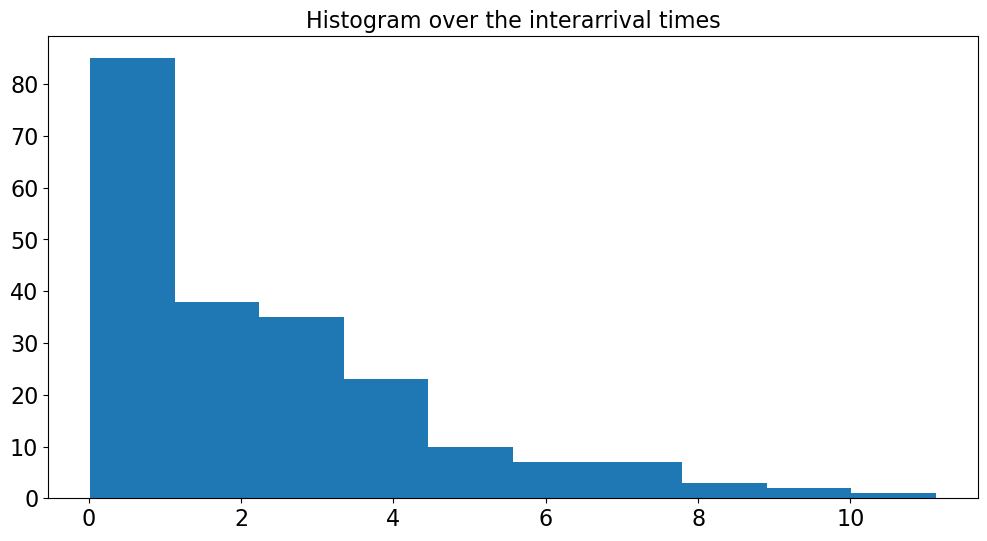

In [5]:
env = simpy.Environment() # Create the simulation environment
lmbda = 0.5 # One arrival per two minutes on average
arr = [] # The list of arrival times
env.process( skier_generator_process(env, lmbda, arr, False) ) # Tell the simulator to process the skier generator process
env.run(until=60*8) # Simulate a day

interArrivalTimes = np.diff(np.array(arr)) # The interarrival times are the difference between the arrival times
plt.figure(figsize=(12,6))
plt.hist(interArrivalTimes)
plt.title('Histogram over the interarrival times')

#### Generación de números aleatorios
Para ver las distribuciones disponibles de las que puedes tomar muestras con el módulo `random`, ejecuta:



In [6]:
?random

Type:        module
String form: <module 'random' from '/Users/alejandrovasquez/miniforge3/lib/python3.10/random.py'>
File:        ~/miniforge3/lib/python3.10/random.py
Docstring:  
Random variable generators.

    bytes
    -----
           uniform bytes (values between 0 and 255)

    integers
    --------
           uniform within range

    sequences
    ---------
           pick random element
           pick random sample
           pick weighted random sample
           generate random permutation

    distributions on the real line:
    ------------------------------
           uniform
           triangular
           normal (Gaussian)
           lognormal
           negative exponential
           gamma
           beta
           pareto
           Weibull

    distributions on the circle (angles 0 to 2pi)
    ---------------------------------------------
           circular uniform
           von Mises

General notes on the underlying Mersenne Twister core generator:

* The pe

Y para ver información sobre una distribución en particular, ejecuta:



In [7]:
?random.expovariate

Signature: random.expovariate(lambd)
Docstring:
Exponential distribution.

lambd is 1.0 divided by the desired mean.  It should be
nonzero.  (The parameter would be called "lambda", but that is
a reserved word in Python.)  Returned values range from 0 to
positive infinity if lambd is positive, and from negative
infinity to 0 if lambd is negative.
File:      ~/miniforge3/lib/python3.10/random.py
Type:      method

### Ejercicio 1
Prueba otra distribución para el tiempo entre llegadas en `skier_generator_proc` y grafica el histograma.



In [ ]:
# Solución aqui


### Ejercicio 2
Ejecuta la simulación varias veces y anota cuántos esquiadores llegan (dado el tiempo medio entre llegadas de tu proceso). ¿Es lo que esperabas?



In [ ]:
# Solución aqui

## Un proceso de llegadas más realista
Obviamente, es poco realista que la frecuencia de llegada de esquiadores sea constante durante todo el día. Probablemente varía a lo largo de la jornada y podría parecerse a la curva de la figura siguiente.



Text(0.5, 0, 'Tiempo [minutos]')

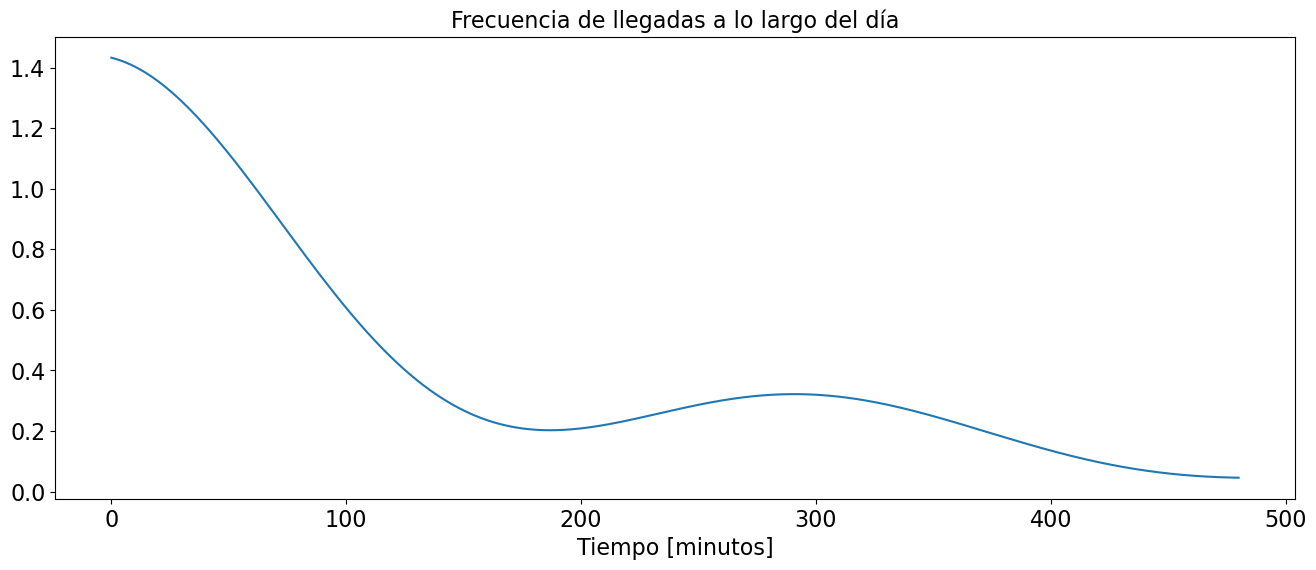

In [8]:
def arrival_freq(t):
    """ Retorna la frecuencia de llegadas como función del tiempo (minutos desde el inicio del día) """
    return np.exp(-t/200)*(1 + 0.5*np.cos(t*2*np.pi/300 - np.pi/6))

t = np.linspace(0, 480, 481)
plt.figure(figsize=(16,6))
plt.plot(t, arrival_freq(t) )
plt.title('Frecuencia de llegadas a lo largo del día')
plt.xlabel('Tiempo [minutos]')

### Ejercicio 3
Observa en el código anterior que se define una función `arrival_freq(t)` que devuelve la frecuencia de llegadas en función del tiempo. Modifica tu `skier_generator_proc` para usar esta función al generar los tiempos entre llegadas.



In [ ]:
# Solución


(0.0, 15.0)

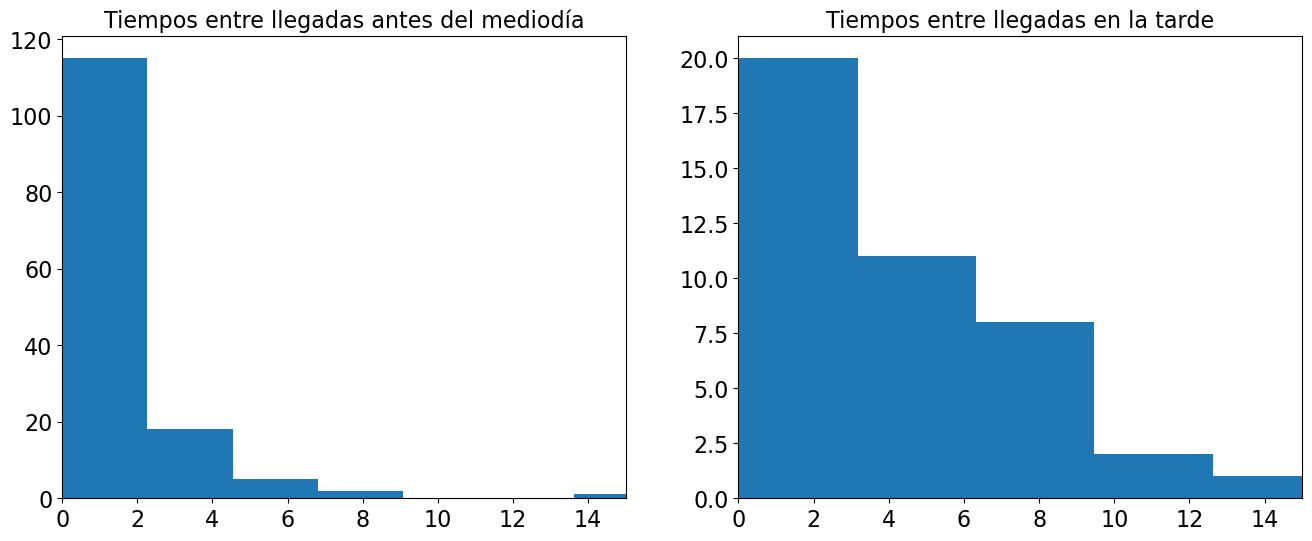

In [9]:
# %load non_stationary_skier_process.py
def skier_generator_process(env, arrivals):
    """ Implementación del proceso que genera la llegada de clientes a la instalación.
    
        Argumentos
        env       --  objeto de entorno de simulación de simpy
        arrivals  --  una lista para almacenar el tiempo de las llegadas
    """
   
    k = 0 # Un contador para indicar el número de esquiadores creados
    while True:
        # Bucle infinito
        yield env.timeout(random.expovariate(arrival_freq(env.now))) # Esperar un intervalo aleatorio, dependiendo de la hora del día
        k += 1
        #print("Time is %6.2f and skier %d arrives" % (env.now, k))
        arrivals.append(env.now) # Registrar el tiempo de llegada
        
env = simpy.Environment() # Crear el entorno de simulación
lmbda = 0.5 # Una llegada cada dos minutos en promedio
arr = [] # La lista de tiempos de llegada
env.process(skier_generator_process(env, arr)) # Indicar al simulador que ejecute el proceso generador de esquiadores
env.run(until=60*8) # Simular un día


interArrivalTimesAM = np.diff(np.array([t for t in arr if t<(12-8)*60])) # Los tiempos entre llegadas en la primera mitad del día
interArrivalTimesPM = np.diff(np.array([t for t in arr if t>(12-8)*60])) # Los tiempos entre llegadas en la segunda mitad del día

plt.figure(figsize=(16,6))
plt.subplot(121)
plt.hist(interArrivalTimesAM)
plt.title('Tiempos entre llegadas antes del mediodía')
plt.xlim((0, 15))
plt.subplot(122)
plt.hist(interArrivalTimesPM)
plt.title('Tiempos entre llegadas en la tarde')
plt.xlim((0, 15))


### El proceso del esquiador
Hasta ahora solo hemos implementado un generador de clientes que registra el momento de llegada. Nuestro objetivo ahora es modelar el proceso de un esquiador.

Hay muchos eventos interesantes que le pueden ocurrir a un esquiador en la estación. Para empezar, veremos un modelo extremadamente simplificado.

Considera un modelo con solo dos eventos: (1) el esquiador llega a la base, y (2) el esquiador sale después de esquiar. Entre ambos hay un **tiempo de retardo (Hold)** entre el evento de llegada y el de salida.

<p align="center">
  <img src="Imagen2.png" alt="Proceso de cliente" width="800"/>
</p>

Necesitamos describir el tiempo pasado en las pista, $T_s$. Esta variable no puede exceder el tiempo que queda hasta que cierre el telesferico. Quizá sea razonable una distribución como la de abajo.



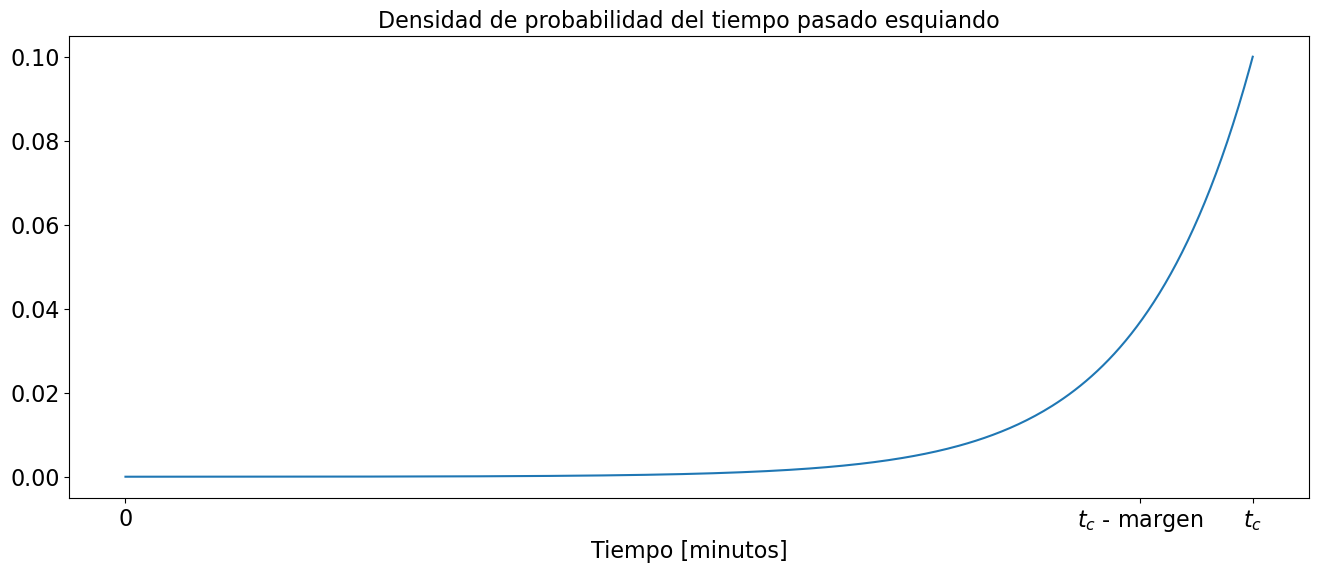

In [10]:
def pdf_time_spent_skiing(t, timeToEndOfDay, meanSlackTime):
    """ 
        Función que describe la densidad de probabilidad del tiempo que un esquiador pasa esquiando,
        dado que llega cuando faltan timeToEndOfDay minutos para que cierre el telesferico.
        El argumento meanSlackTime es el tiempo promedio de margen desde que el esquiador se retira
        hasta que el telesilla realmente cierra.
    """
    return 1.0/meanSlackTime * np.exp(-1.0/meanSlackTime * (timeToEndOfDay-t))

timeToClosing = 100
slackTime = 10
t = np.linspace(0, timeToClosing, 400)

plt.figure(figsize=(16,6))
plt.plot(t, pdf_time_spent_skiing(t, timeToClosing, slackTime))
plt.title('Densidad de probabilidad del tiempo pasado esquiando')
plt.xlabel('Tiempo [minutos]')
xt = plt.xticks([0, timeToClosing-slackTime, timeToClosing], ['0', '$t_c$ - margen', '$t_c$'])

Esta distribución se obtuvo básicamente recortando y reflejando una distribución para que nunca supere el límite $t_c$, que es el tiempo que queda hasta que el telesferico cierre.

A continuación se muestra una implementación del proceso del esquiador y una versión actualizada del generador de esquiadores.



In [11]:
def skier_proc(env, name, slackTime, population):
    """
        Proceso que describe a un esquiador.
    
        Argumentos
        env        -- el objeto de entorno de simulación
        name       -- el nombre del esquiador
        slackTime  -- el tiempo medio antes del cierre del telesilla en el que un esquiador se retirará
        population -- una lista que contiene los nombres de los esquiadores actualmente en la instalación
    """
    
    #print("Time is %6.2f and %s is arriving." % (env.now, name))
    population.append(name) # Agregar el nombre a la lista de personas esquiando
    timeLeft = 480 - env.now  # Minutos restantes del día
    timeSkiing = timeLeft - random.expovariate(1.0/slackTime) # Muestra de la distribución 
    yield env.timeout(np.max((0, timeSkiing))) # Asegurarse de no obtener accidentalmente un valor negativo
    #print("Time is %6.2f and %s is leaving." % (env.now, name))
    population.remove(name) 
    
    
def skier_generator_process(env, slackTime, population, arrivals):
    """ Implementación del proceso que genera la llegada de clientes a la instalación.
    
        Argumentos
        env        --  objeto de entorno de simulación de simpy
        slackTime  --  el tiempo medio antes del cierre del telesilla en el que un esquiador se retirará
        population --  una lista que contiene los nombres de los esquiadores actualmente en la instalación
        arrivals   --  una lista para almacenar el tiempo de las llegadas
    """
   
    k = 0 # Un contador para indicar el número de esquiadores creados
    while True:
        # Bucle infinito
        yield env.timeout(random.expovariate(arrival_freq(env.now))) # Esperar un intervalo aleatorio
        k += 1
        env.process(skier_proc(env, "Esquiador-%d" % k, 10, population)) # Generar e iniciar el proceso de un esquiador
        arrivals.append(env.now) # Registrar el tiempo de llegada

env = simpy.Environment() # Crear el entorno de simulación
slackT = 15
arr = [] # La lista de tiempos de llegada
pop = [] # Lista de personas en la instalación
env.process(skier_generator_process(env, slackT, pop, arr)) # Procesar el generador de esquiadores
env.run(until=60*8 - 1) # Simular hasta que falte 1 minuto para cerrar el día
print("Esquiadores restantes cuando falta un minuto para el cierre:")
print(pop) # ¿Queda alguien en las pistas?


arr = [] # La lista de tiempos de llegada
pop = [] # Lista de personas en la instalación
env.process(skier_generator_process(env, slackT, pop, arr)) # Procesar el generador de esquiadores
env.run(until=60*8) # Simular todo el día
print("Esquiadores restantes en el momento del cierre:")
print(pop) # ¿Queda alguien en las pistas?


Esquiadores restantes cuando falta un minuto para el cierre:
['Esquiador-21', 'Esquiador-22', 'Esquiador-27', 'Esquiador-45', 'Esquiador-50', 'Esquiador-64', 'Esquiador-83', 'Esquiador-90', 'Esquiador-100', 'Esquiador-123', 'Esquiador-138', 'Esquiador-156']
Esquiadores restantes en el momento del cierre:
[]


### Ejercicio 4
Modifica el código anterior para que puedas registrar el **número de esquiadores en cola** y el **tiempo máximo de espera (pico)** durante el día. ¿Qué sucede con estos valores si cambias el *slack time* (tiempo de holgura) antes del cierre?



In [ ]:
# YOUR CODE HERE

### Proceso para el telesferico
Gran parte de un día en las pistas implica hacer fila para el telesilla. El flujo básico es: llegar a la base, esperar, subir y empezar a esquiar. Mientras tanto, otro esquiador llega a la base del telesferico, generando colas.

Consideramos aquí un único telesferico con sillas de dos plazas. La distancia hasta la cima es de 600 m y hay 12 m entre sillas.

Hay dos maneras de modelar el telesferico:
1. Hay $1200/12 = 100$ sillas dobles. Un ciclo de cada silla toma un tiempo fijo (sube y baja). En la cima de la pista la silla debe soltar al(los) esquiador(es).
2. Una vez que un esquiador se sube a la silla, el trayecto hasta la cima dura un tiempo fijo. Podemos tratar a cada silla como un proceso independiente, es decir, como **procesos de silla**. Este modelo se describe en el diagrama de flujo siguiente.


<p align="center">
  <img src="Imagen3.png" alt="Proceso del telesferico" width="800"/>
</p>



In [12]:
def skilift_proc(env, queue, timeBetweenChairs=4.0/60, seatsPerChair=2 ):
    """
        Implementación del proceso del telesilla
        
        Argumentos
        env               -- el objeto de entorno de simulación
        queue             -- una lista con los esquiadores en espera. 
                             Cada esquiador está representado por un objeto evento 
                             que se activará una vez que el esquiador esté en la silla.
        timeBetweenChairs -- el modelo asume velocidad constante del telesilla
        seatsPerChair     -- número máximo de esquiadores que caben en una silla
    """
    while True:
        skiersToPickup = np.min((seatsPerChair, len(queue)))
        if skiersToPickup:
            for i in range(skiersToPickup):
                skier = queue.pop(0) # Tomar del frente de la fila
                skier.succeed() # Esto le indica al esquiador que ya está en la silla
        yield env.timeout(timeBetweenChairs) # Esperar hasta que llegue la siguiente silla



### Un modelo más interesante para los esquiadores
Los esquiadores llegan a la base del telesilla y entran en la cola. Esperan por una silla libre (un **recurso**), suben hasta la cima, bajan esquiando y repiten el ciclo hasta que sea hora de irse a casa. El proceso se ilustra a continuación.

<p align="center">
  <img src="Imagen4.png" alt="Proceso del esquiador" width="800"/>
</p>

Necesitaremos un modelo para el tiempo que toma descender hasta el final de la pista. Claramente, existe un tiempo mínimo posible cuando la única fuerza impulsora es la gravedad. Supongamos que es de 1 minuto. La mayoría de los esquiadores emplea más o menos el mismo tiempo, con algunos principiantes más lentos y algunos corredores temerarios muy rápidos. Una función de densidad de probabilidad adecuada para la distribución de los tiempos de descenso podría parecerse a la siguiente, que corresponde a una *distribución Erlang*, aquí con parámetro de forma 3, y desplazada en 1 unidad hacia la derecha.

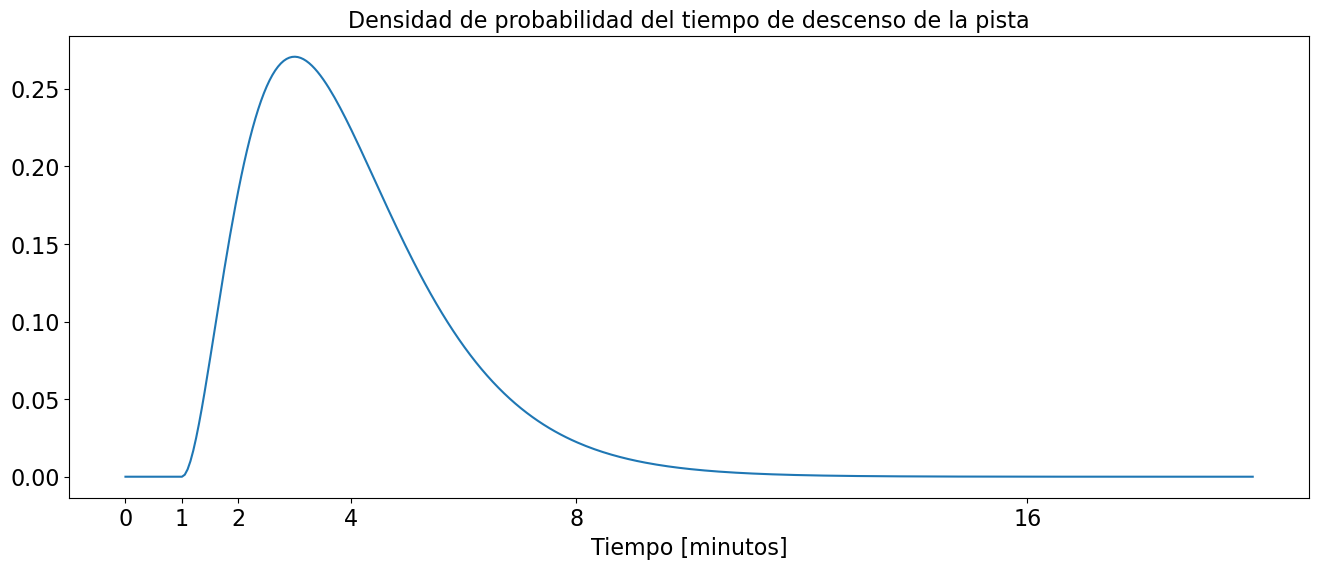

In [13]:
from scipy.stats import erlang
t = np.linspace(0, 20, 400)
plt.figure(figsize=(16,6))
plt.plot(t, erlang.pdf(t, 3, 1))
plt.title('Densidad de probabilidad del tiempo de descenso de la pista')
plt.xlabel('Tiempo [minutos]')
xt = plt.xticks([0, 1, 2, 4, 8, 16])


Ahora estamos listos para implementar el proceso de esquiador más realista.



In [14]:
import pdb
def skier_proc(env, name, slackTime, queue, population):
    """
        Implementación del proceso de un esquiador. El esquiador hará fila para el telesilla,
        subirá, descenderá y repetirá hasta que sea hora de irse a casa.
        Se mide el tiempo acumulado pasado en la fila.
        
        Argumentos
        env          -- el objeto de entorno de simulación
        name         -- nombre único para cada esquiador
        slackTime    -- el tiempo medio antes del cierre del telesilla en el que un esquiador se retirará
        queue        -- una lista con los esquiadores esperando el telesilla
        population   -- una lista con los nombres de los esquiadores actualmente en la instalación
    """
    population.append(name) # Agregar el nombre a la lista de personas esquiando
    timeToPackup = 480 - random.expovariate(1.0/slackTime) # Muestra de la distribución 
    timeInQ = 0
    while env.now < timeToPackup:
        onChairEvent = env.event() # Generar un evento que será activado por el telesilla
        queue.append(onChairEvent) # El esquiador en la fila está representado por su objeto evento
        timeWhenEnteringQ = env.now
        yield onChairEvent         # Esperar hasta que se active el evento del telesilla
        timeInQ += (env.now - timeWhenEnteringQ)
        # Continúa aquí cuando esté en la silla
        yield env.timeout(200/60)  # Esperar el tiempo que toma subir
        timeDownhill = 1.0 + random.gammavariate(3, 1)  # El tiempo que toma descender
        yield env.timeout(timeDownhill) 
        
    print("La hora es %6.2f y %s se retira, habiendo pasado %6.2f minutos esperando en la fila" % (env.now, name, timeInQ))
    population.remove(name) 

def skier_generator_process(env, slackTime, queue, population, arrivals):
    """ Implementación del proceso que genera la llegada de clientes a la instalación.
    
        Argumentos
        env        --  objeto de entorno de simulación de simpy
        slackTime  --  el tiempo medio antes del cierre del telesilla en el que un esquiador se retirará 
        queue      --  una lista con los esquiadores esperando el telesilla
        population --  una lista con los nombres de los esquiadores actualmente en la instalación
        arrivals   --  una lista para almacenar el tiempo de las llegadas
    """
   
    k = 0 # Un contador para indicar el número de esquiadores creados
    while True:
        # Bucle infinito
        yield env.timeout(random.expovariate(arrival_freq(env.now))) # Esperar un intervalo aleatorio
        k += 1
        env.process(skier_proc(env, "Esquiador-%d" % k, 10, queue, population)) # Generar e iniciar el proceso de un esquiador
        arrivals.append(env.now) # Registrar el tiempo de llegada

env = simpy.Environment() # Crear el entorno de simulación
slackT = 15
arr = [] # La lista de tiempos de llegada
pop = [] # Lista de personas en la instalación
queue = [] # La fila al pie del telesilla
env.process(skilift_proc(env, queue))
env.process(skier_generator_process(env, slackT, queue, pop, arr)) # Procesar el generador de esquiadores
env.run(until=60*8 - 1) # Simular hasta que falte 1 minuto para cerrar el día
print("Esquiadores restantes en la fila cuando falta un minuto para el cierre:")
print(queue) # ¿Queda alguien en las pistas?



La hora es 433.68 y Esquiador-82 se retira, habiendo pasado   4.51 minutos esperando en la fila
La hora es 434.84 y Esquiador-29 se retira, habiendo pasado   5.73 minutos esperando en la fila
La hora es 443.56 y Esquiador-105 se retira, habiendo pasado   4.54 minutos esperando en la fila
La hora es 445.15 y Esquiador-210 se retira, habiendo pasado   1.00 minutos esperando en la fila
La hora es 446.48 y Esquiador-191 se retira, habiendo pasado   2.27 minutos esperando en la fila
La hora es 450.77 y Esquiador-103 se retira, habiendo pasado   4.83 minutos esperando en la fila
La hora es 451.67 y Esquiador-27 se retira, habiendo pasado   4.71 minutos esperando en la fila
La hora es 454.81 y Esquiador-59 se retira, habiendo pasado   5.34 minutos esperando en la fila
La hora es 455.55 y Esquiador-99 se retira, habiendo pasado   4.78 minutos esperando en la fila
La hora es 457.52 y Esquiador-83 se retira, habiendo pasado   4.01 minutos esperando en la fila
La hora es 458.25 y Esquiador-26 se 

### Ejercicio 5
Modifica el código anterior para que puedas registrar el **tiempo total pasado en cola** por cada esquiador. ¿Cómo cambia si duplicamos la capacidad de las sillas (4 plazas en lugar de 2)?



In [ ]:
# Solución


### Ejercicio 6
Modifica el código para que puedas registrar el **número de sillas no utilizadas** durante el día. Propón una métrica de desempeño a partir de este dato y calcula su valor para el modelo de simulación.



In [ ]:
# Solución